In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
import sys
sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
from read_datasets import read_dataset

In [2]:
bar = read_dataset(
    dataset='barra-r2',
    resolution='hourly',
    date='2020-07'
)

2026-02-05 21:10:22,526:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)

No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)



In [6]:
date = '2020'

def preprocess(_ds):
    return _ds.sel(
        latitude=slice(bar.lat.max(), bar.lat.min()),
        longitude=slice(bar.lon.min(), bar.lon.max())
    ).rename(
        {'latitude':'lat',
        'longitude':'lon'}
    )
path = Path('/g/data/su28/weatherfeatures.era5/mincl/cdf/')
files = [f for f in path.rglob(f'*{date}*.nc')]
ds = xr.open_mfdataset(files)
ds = ds.isel(dimz_INPUT=0)

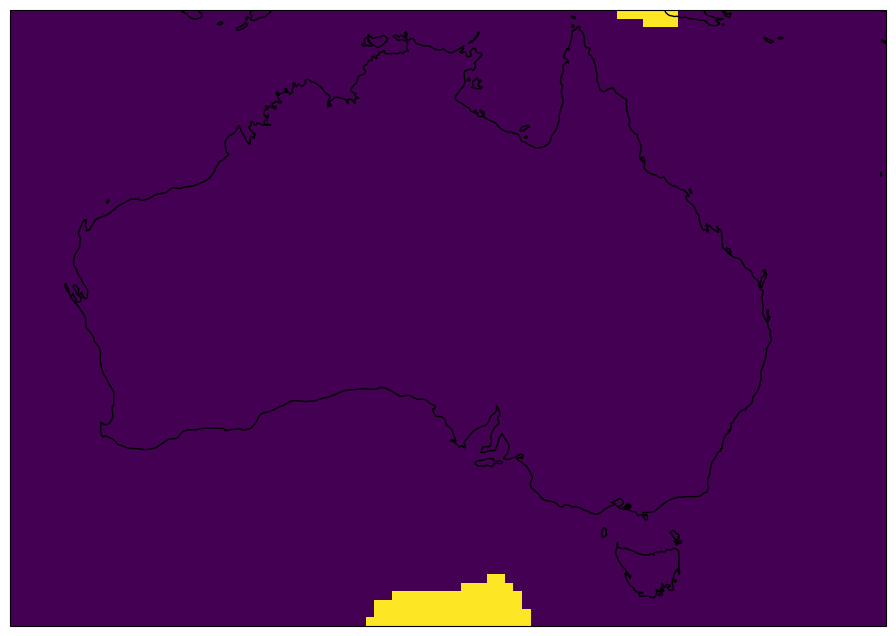

In [54]:
data = ds.INPUT.isel(time=10).sel(lat=slice(-45, -10), lon=slice(110, 160))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
mesh = ax.pcolormesh(
    data.lon,
    data.lat,
    data,
    cmap='viridis',
    shading='auto',
    transform=ccrs.PlateCarree(),
)
ax.coastlines()

# mesh_dif = ax2.pcolormesh(
#     him_data.lon, him_data.lat, diff,
#     cmap='RdBu_r', vmin=-500, vmax=500,
#     shading='auto', transform=ccrs.PlateCarree()
# )